In [1]:
import numpy as np
import rasterio
from rasterio.windows import Window
from rasterio.mask import mask
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from typing import Tuple, List, Dict
from tqdm import tqdm
import os
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import zoom
import numpy as np
import numpy as np
import random
import json
from pathlib import Path
from typing import Dict, List, Tuple
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from typing import Dict, Tuple
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from pathlib import Path

from data_loader import (
    load_dem, load_infiltration_map, load_landuse_map, load_manila_mask, load_all_flood_maps, get_raster_stats, print_raster_stats,
    load_all_rainfall_scenarios, get_rainfall_stats, print_rainfall_stats
)

from data_loader import (
    visualize_raster, visualize_flood_maps_grid,
     visualize_all_rainfall_scenarios
)

from data_preprocessing import (
    normalize_dem, normalize_infiltration, normalize_landuse, handle_nodata
)

from flood_maps import (
    FLOOD_CLASSES, reconstruct_map_from_patches, categorize_all_flood_maps_patch, visualize_all_categorized_maps
)

from vit_architecture import get_model_summary

from model_config import create_small_regularized_model

from training import train_kfold, calculate_class_weights


from testing import (
    evaluate_test_scenarios,
    plot_confusion_matrix,
    plot_scenario_comparison,
    reconstruct_test_map_from_patches
)

NUM_SCENARIO = 20
PATCH_SIZE = 4

# Hyperparameters
BATCH_SIZE = 64
NUM_WORKERS = 4     
PIN_MEMORY = False 

colors = [FLOOD_CLASSES[i]['color'] for i in range(5)]
cmap = ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
norm = BoundaryNorm(bounds, cmap.N)


''' PATCH_CLASSES_RESILIENCY = { 
    0: (0.0, 0.32),   
    1: (0.32, 0.48),  
    2: (0.48, 0.97),   
    3: (0.97, 1.46),   
    4: (1.46, float('inf'))
}

PATCH_CLASSES_SUSCEPTIBILITY = {
    0: (0.0, 0.15),      
    1: (0.15, 0.24),           
    2: (0.24, 0.46),            
    3: (0.46, 0.68),           
    4: (0.68, float('inf'))       
}
'''


" PATCH_CLASSES_RESILIENCY = { \n    0: (0.0, 0.32),   \n    1: (0.32, 0.48),  \n    2: (0.48, 0.97),   \n    3: (0.97, 1.46),   \n    4: (1.46, float('inf'))\n}\n\nPATCH_CLASSES_SUSCEPTIBILITY = {\n    0: (0.0, 0.15),      \n    1: (0.15, 0.24),           \n    2: (0.24, 0.46),            \n    3: (0.46, 0.68),           \n    4: (0.68, float('inf'))       \n}\n"

In [2]:
repo_root = os.getcwd()
gmm_path = os.path.join(repo_root, "COP-30m-GMM")
manila_path = os.path.join(repo_root, "COP-30m-ManilaOnly")
rs_path = os.path.join(repo_root, "mm_hr_scenarios")

# Loading data

In [3]:
# Load DEM
print("\n--- Loading DEM ---")
dem_path = os.path.join(manila_path, "by_box", "manila_bbox_dem_cop.tif")
if os.path.exists(dem_path):
    dem_data, dem_meta = load_dem(dem_path)
    dem_stats = get_raster_stats(dem_data, "DEM")
    print_raster_stats(dem_stats)
else:
    print(f"WARNING: DEM file not found at {dem_path}")
    dem_data = None



--- Loading DEM ---
DEM loaded: shape (320, 320), dtype float32

Statistics for: DEM
Shape:         (320, 320)
Dtype:         float32
Min value:     -9.1316
Max value:     46.7424
Mean value:    6.1565
Std dev:       5.5713
Valid pixels:  102,400 / 102,400



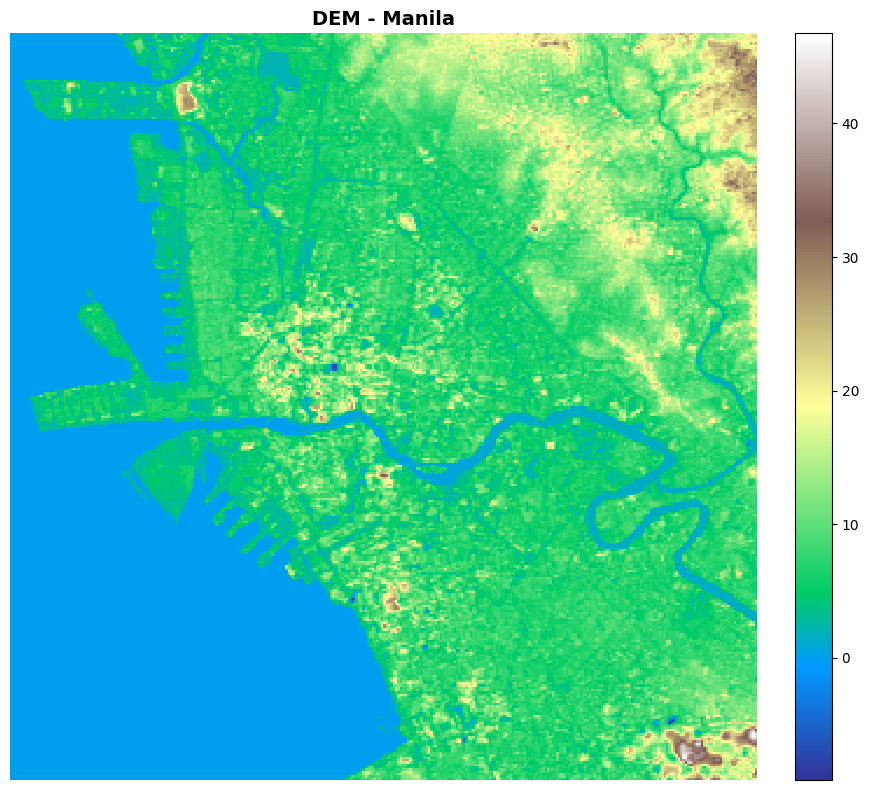

In [4]:
fig1 = visualize_raster(dem_data, title="DEM - Manila", cmap='terrain')

In [5]:
# Load Infiltration Map
print("\n--- Loading Infiltration Map ---")
infilt_path = os.path.join(manila_path, "by_box", "GM_Infilt_Manila_box.tif")
if os.path.exists(infilt_path):
    infilt_data, infilt_meta = load_infiltration_map(infilt_path)
    infilt_stats = get_raster_stats(infilt_data, "Infiltration Map")
    print_raster_stats(infilt_stats)
else:
    print(f"WARNING: Infiltration file not found at {infilt_path}")
    infilt_data = None


--- Loading Infiltration Map ---
Infiltration map loaded: shape (320, 320), dtype float64

Statistics for: Infiltration Map
Shape:         (320, 320)
Dtype:         float64
Min value:     0.0000
Max value:     2.7687
Mean value:    0.0127
Std dev:       0.1795
Valid pixels:  102,400 / 102,400



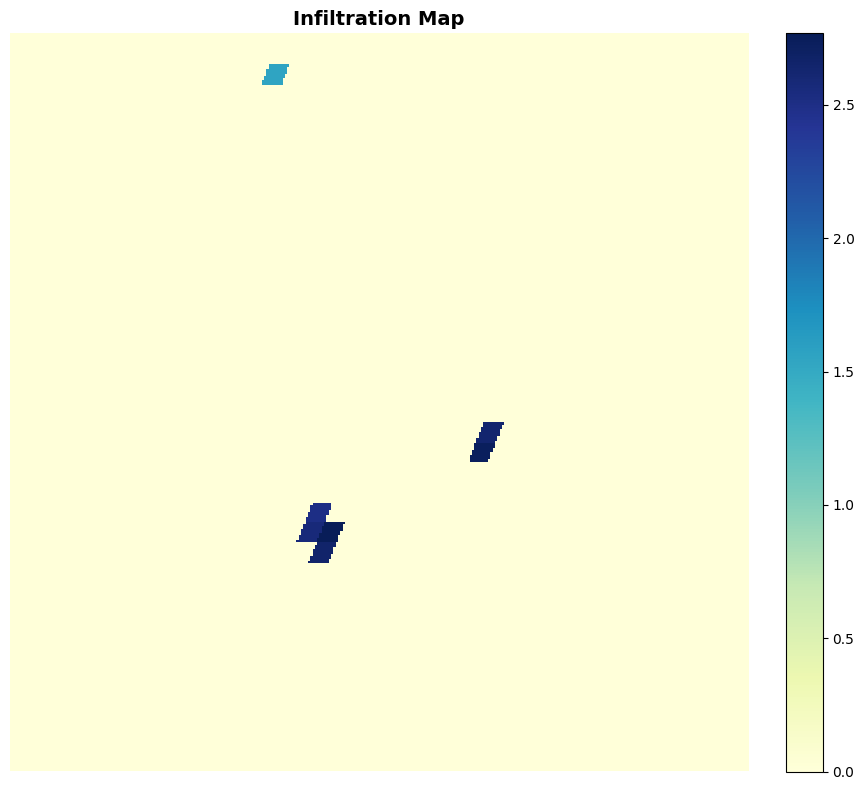

In [6]:
fig2 = visualize_raster(infilt_data, title="Infiltration Map", cmap='YlGnBu')

In [7]:
# Load Landuse Map
print("\n--- Loading Landuse Map ---")
landuse_path = os.path.join(manila_path, "by_box", "GM_LU_Manila_box.tif")
if os.path.exists(landuse_path):
    landuse_data, landuse_meta = load_landuse_map(landuse_path)
    landuse_stats = get_raster_stats(landuse_data, "Landuse Map")
    print_raster_stats(landuse_stats)
else:
    print(f"WARNING: Landuse file not found at {landuse_path}")
    landuse_data = None



--- Loading Landuse Map ---
Landuse map loaded: shape (320, 320), dtype float64

Statistics for: Landuse Map
Shape:         (320, 320)
Dtype:         float64
Min value:     1.0000
Max value:     11.0000
Mean value:    5.7151
Std dev:       1.6457
Valid pixels:  102,400 / 102,400



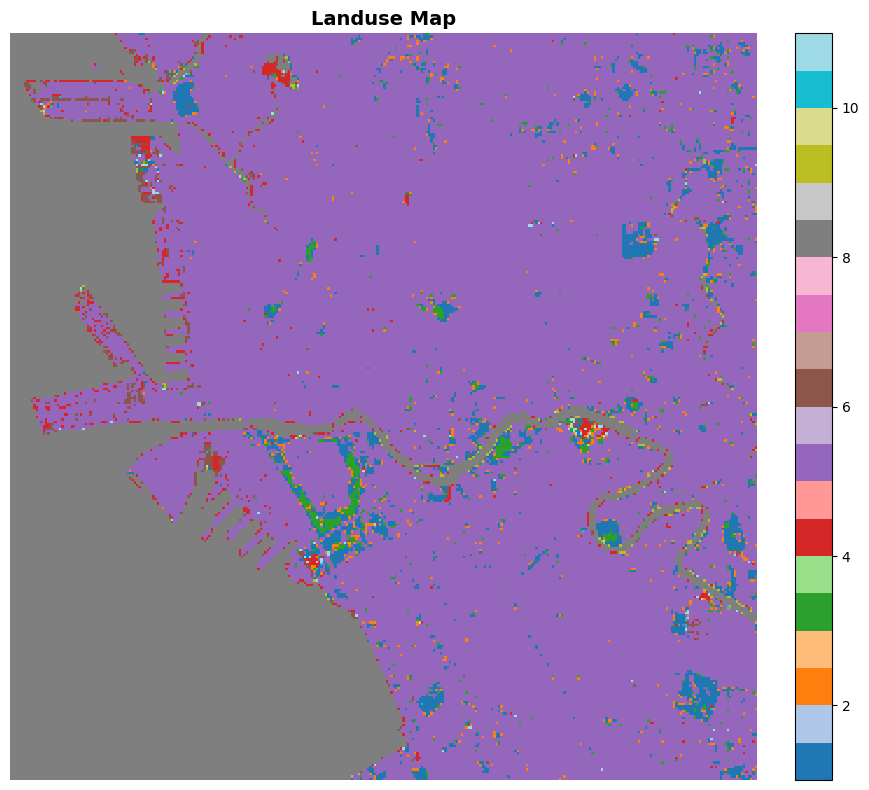

In [8]:
fig3 = visualize_raster(landuse_data, title="Landuse Map", cmap='tab20')

In [9]:
# Load Manila Mask
print("\n--- Loading Manila Mask ---")
mask_path = os.path.join(manila_path, "manila_box_3857.tif")
if os.path.exists(mask_path):
    mask_data, mask_meta = load_manila_mask(mask_path)
    mask_stats = get_raster_stats(mask_data, "Manila Mask")
    print_raster_stats(mask_stats)
else:
    print(f"WARNING: Mask file not found at {mask_path}")
    mask_data = None


--- Loading Manila Mask ---
Manila mask loaded: shape (389, 358), dtype float32

Statistics for: Manila Mask
Shape:         (389, 358)
Dtype:         float32
Min value:     0.0000
Max value:     1.0000
Mean value:    0.0747
Std dev:       0.2629
Valid pixels:  139,262 / 139,262



In [10]:
# Load all flood maps
print("\n--- Loading Flood Maps (Ground Truth) ---")
fm_path = os.path.join(manila_path, "by_box")
flood_maps, flood_metadata = load_all_flood_maps(fm_path, num_scenarios=NUM_SCENARIO)

if len(flood_maps) > 0:
    print(f"\nFlood maps successfully loaded: {len(flood_maps)}")
    
    if len(flood_maps) >= NUM_SCENARIO:
        flood_stats = get_raster_stats(flood_maps[-1], "Flood Map RS20")
else:
    print("WARNING: No flood maps loaded!")


--- Loading Flood Maps (Ground Truth) ---
Flood map RS1 loaded: shape (320, 320), dtype float64
Flood map RS2 loaded: shape (320, 320), dtype float64
Flood map RS3 loaded: shape (320, 320), dtype float64
Flood map RS4 loaded: shape (320, 320), dtype float64
Flood map RS5 loaded: shape (320, 320), dtype float64
Flood map RS6 loaded: shape (320, 320), dtype float64
Flood map RS7 loaded: shape (320, 320), dtype float64
Flood map RS8 loaded: shape (320, 320), dtype float64
Flood map RS9 loaded: shape (320, 320), dtype float64
Flood map RS10 loaded: shape (320, 320), dtype float64
Flood map RS11 loaded: shape (320, 320), dtype float64
Flood map RS12 loaded: shape (320, 320), dtype float64
Flood map RS13 loaded: shape (320, 320), dtype float64
Flood map RS14 loaded: shape (320, 320), dtype float64
Flood map RS15 loaded: shape (320, 320), dtype float64
Flood map RS16 loaded: shape (320, 320), dtype float64
Flood map RS17 loaded: shape (320, 320), dtype float64
Flood map RS18 loaded: shape (3

In [11]:
print_raster_stats(flood_stats)


Statistics for: Flood Map RS20
Shape:         (320, 320)
Dtype:         float64
Min value:     0.0000
Max value:     7.3680
Mean value:    0.3187
Std dev:       0.6177
Valid pixels:  102,400 / 102,400



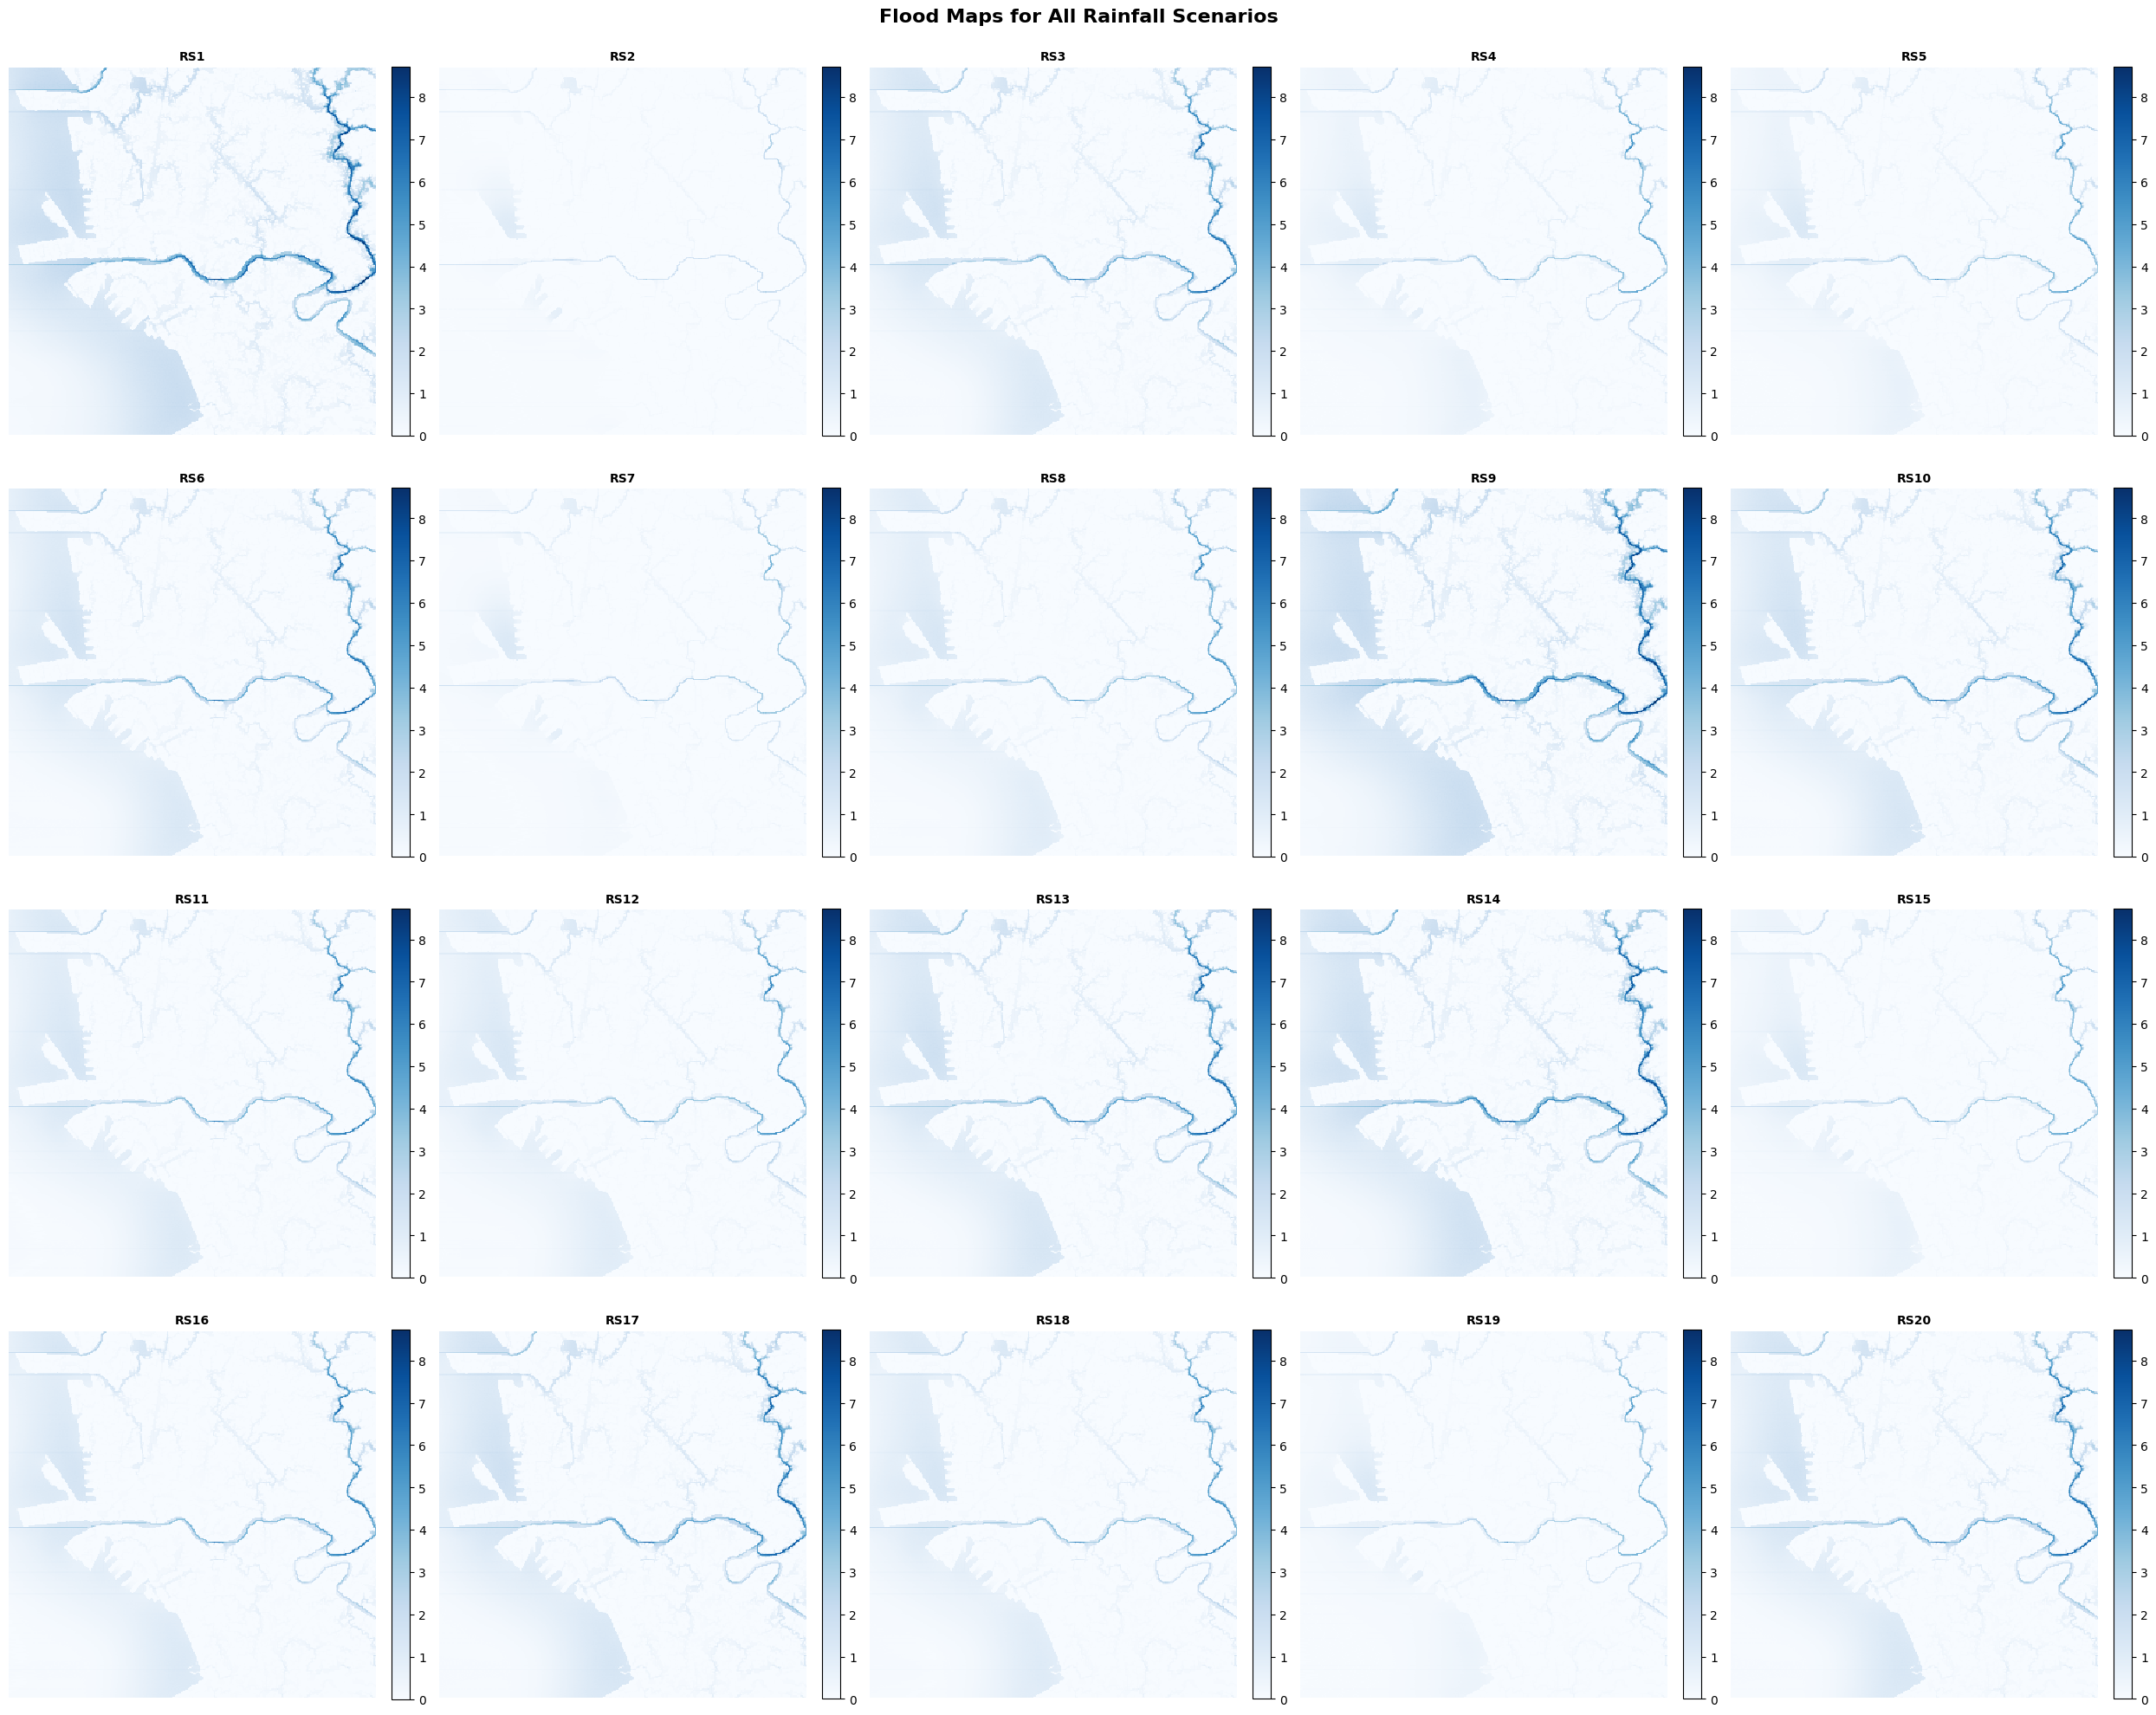

In [12]:
fig4 = visualize_flood_maps_grid(flood_maps=flood_maps,scenario_ids=list(range(1, 21)),figsize=(25, 20),ncols=5,cmap='Blues')
#plt.show()

In [13]:
print("LOADING RAINFALL SCENARIOS")
# Load rainfall scenarios
rainfall_scenarios = load_all_rainfall_scenarios(rs_path, num_scenarios=20)

if len(rainfall_scenarios) > 0:
    print(f"\nRainfall scenarios successfully loaded: {len(rainfall_scenarios)}")
    
    if len(rainfall_scenarios) >= NUM_SCENARIO:
        rain_stats = get_rainfall_stats(rainfall_scenarios[-1], scenario_id=20)
else:
    print("WARNING: No rainfall scenarios loaded!")

LOADING RAINFALL SCENARIOS
Rainfall Scenario 1 loaded: 13 time steps
Rainfall Scenario 2 loaded: 13 time steps
Rainfall Scenario 3 loaded: 13 time steps
Rainfall Scenario 4 loaded: 13 time steps
Rainfall Scenario 5 loaded: 13 time steps
Rainfall Scenario 6 loaded: 13 time steps
Rainfall Scenario 7 loaded: 13 time steps
Rainfall Scenario 8 loaded: 13 time steps
Rainfall Scenario 9 loaded: 13 time steps
Rainfall Scenario 10 loaded: 13 time steps
Rainfall Scenario 11 loaded: 13 time steps
Rainfall Scenario 12 loaded: 13 time steps
Rainfall Scenario 13 loaded: 13 time steps
Rainfall Scenario 14 loaded: 13 time steps
Rainfall Scenario 15 loaded: 13 time steps
Rainfall Scenario 16 loaded: 13 time steps
Rainfall Scenario 17 loaded: 13 time steps
Rainfall Scenario 18 loaded: 13 time steps
Rainfall Scenario 19 loaded: 13 time steps
Rainfall Scenario 20 loaded: 13 time steps

Total rainfall scenarios loaded: 20

Rainfall scenarios successfully loaded: 20


In [14]:
print_rainfall_stats(rain_stats)
display(rainfall_scenarios)


Rainfall Scenario 20 Statistics
Duration:          1.00 hours
Time steps:        13
Max intensity:     78.8855 mm/hr
Mean intensity:    43.3846 mm/hr
Total rainfall:    47.00 mm
Peak at hour:      0.4167



[        hour  intensity_mmhr
 0   0.000000       39.722227
 1   0.083333       82.817226
 2   0.166667       92.492529
 3   0.250000       82.988129
 4   0.333333       64.674010
 5   0.416667       44.595223
 6   0.500000       27.016951
 7   0.583333       13.969586
 8   0.666667        5.793798
 9   0.750000        1.685605
 10  0.833333        0.241450
 11  0.916667        0.003265
 12  1.000000        0.000000,
         hour  intensity_mmhr
 0   0.000000        6.271931
 1   0.083333       13.076404
 2   0.166667       14.604084
 3   0.250000       13.103389
 4   0.333333       10.211686
 5   0.416667        7.041351
 6   0.500000        4.265834
 7   0.583333        2.205724
 8   0.666667        0.914810
 9   0.750000        0.266148
 10  0.833333        0.038124
 11  0.916667        0.000515
 12  1.000000        0.000000,
         hour  intensity_mmhr
 0   0.000000       35.540940
 1   0.083333       74.099623
 2   0.166667       82.756473
 3   0.250000       74.252536
 4   0.3

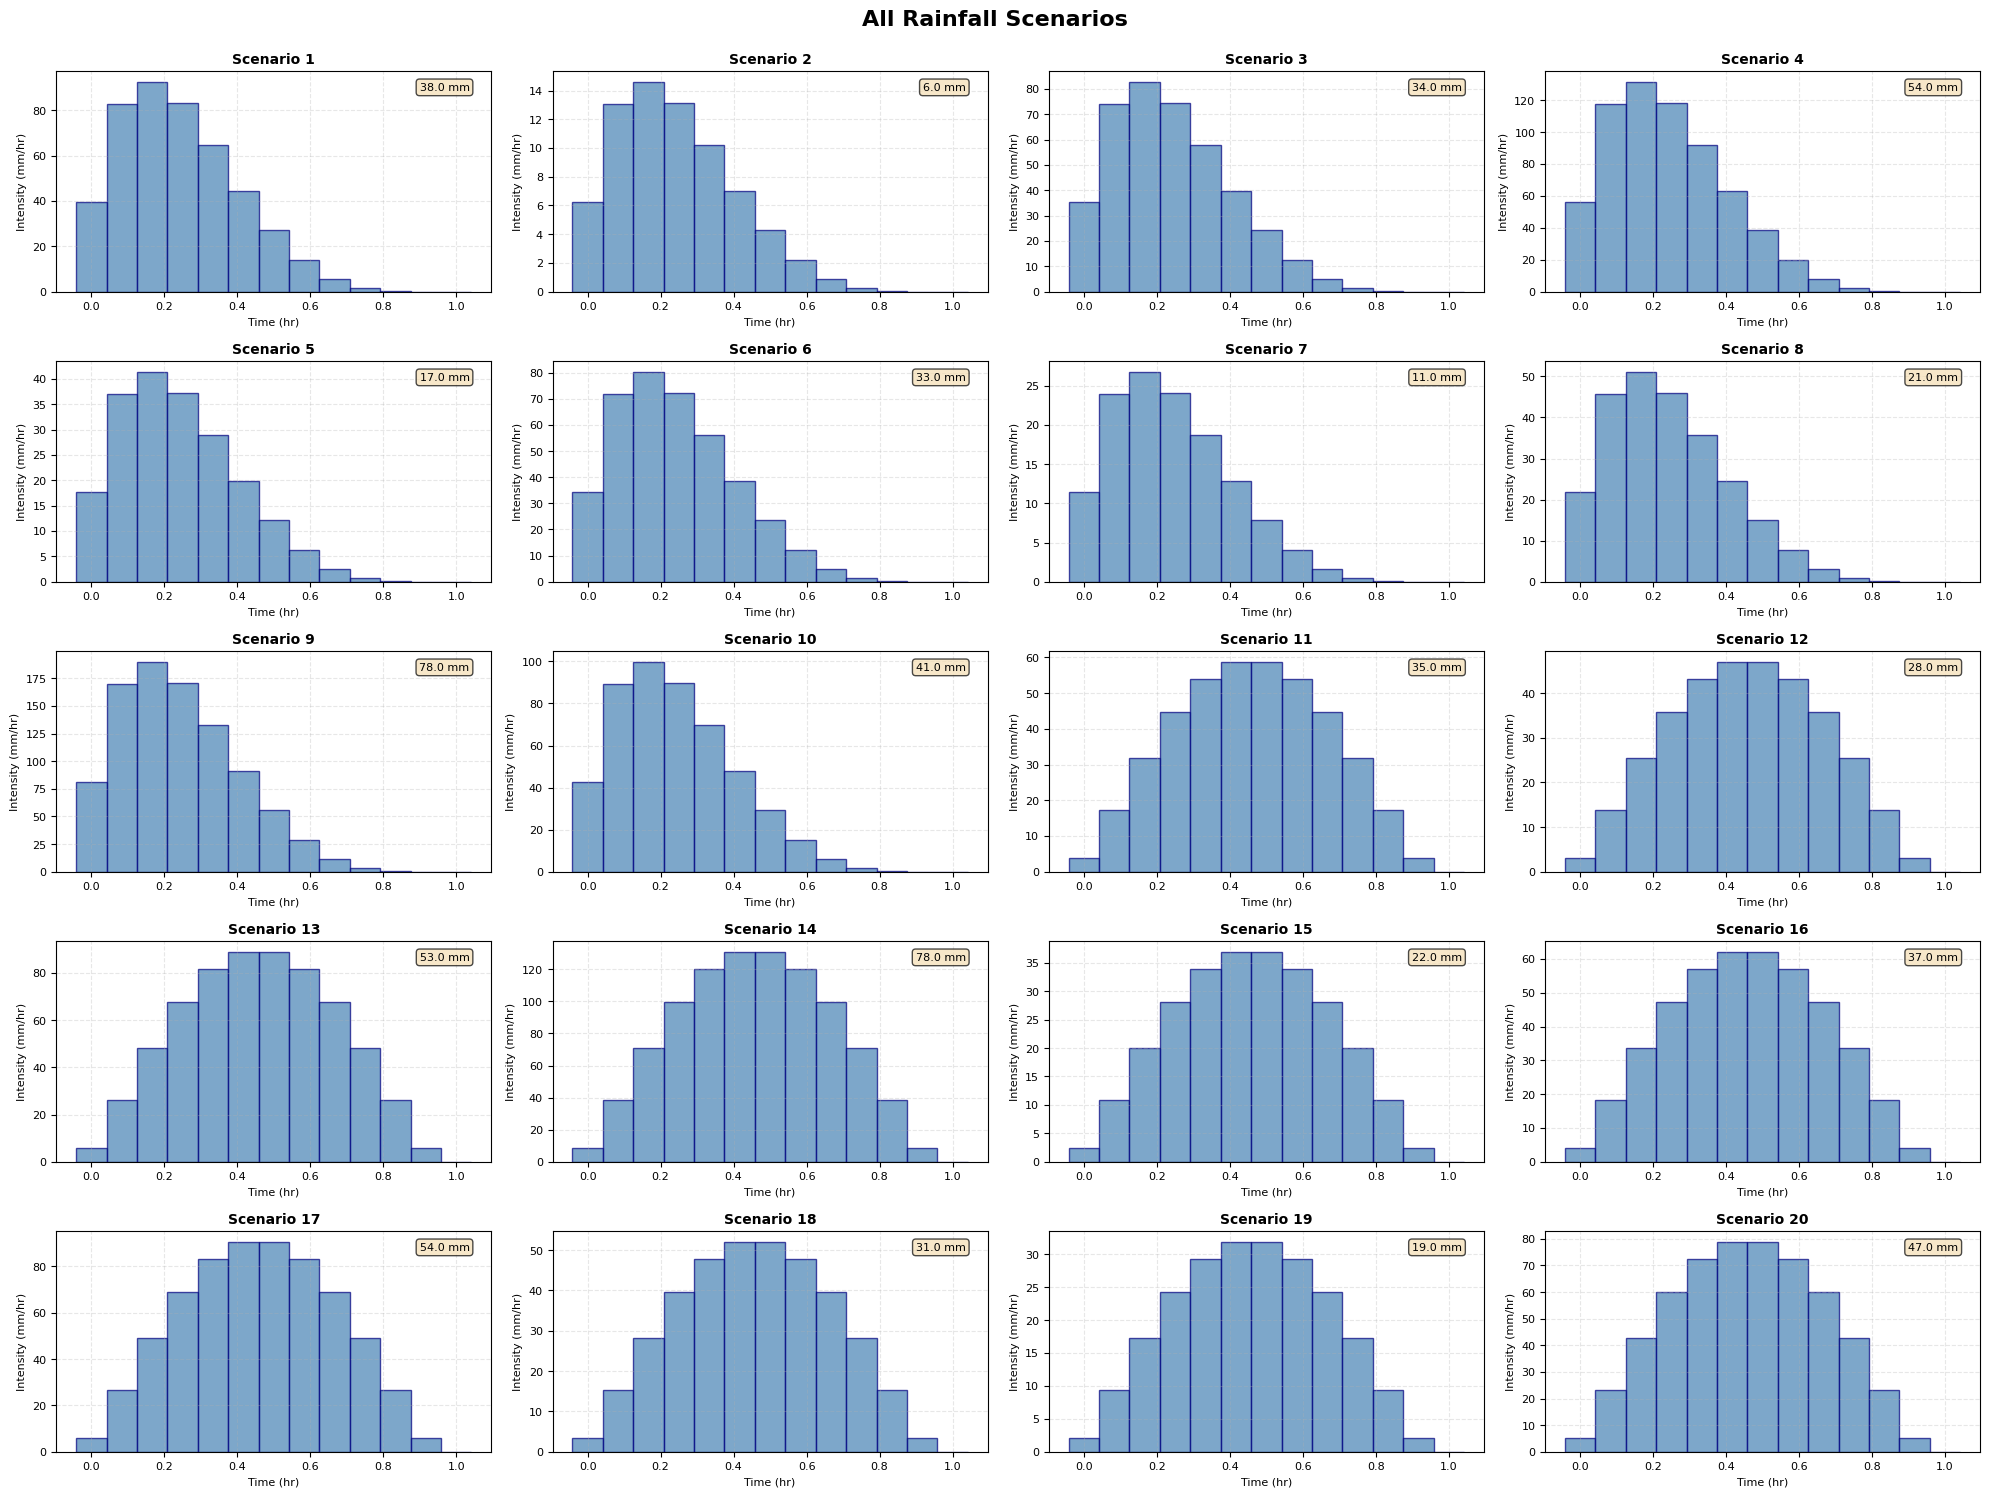

In [15]:
fig5 = visualize_all_rainfall_scenarios(rainfall_scenarios, figsize=(20, 15), ncols=4)
#plt.show()

# Data Preprocessing

## Handle NoData

In [16]:
print("\nProcessing DEM...")
dem_clean = handle_nodata(
    dem_data, 
    nodata_value=dem_meta.get('nodata'),
    fill_method='mean'  # Options: 'mean', 'median', 'zero', 'interpolate'
)
# Verify
# dem_clean_stats = get_raster_stats(dem_clean, "DEM (NoData Handled)")
# print_raster_stats(dem_clean_stats)


Processing DEM...

Handling NoData for Raster...
  NoData pixels: 0 / 102,400 (0.00%)
  ✓ No NoData values found


In [17]:
# 2. Handle NoData in Infiltration
print("\nProcessing Infiltration...")
infilt_clean = handle_nodata(
    infilt_data,
    nodata_value=infilt_meta.get('nodata'),
    fill_method='mean'  # Options: 'mean', 'median', 'zero', 'interpolate'
)

# Verify
# infilt_clean_stats = get_raster_stats(infilt_clean, "Infiltration (NoData Handled)")
# print_raster_stats(infilt_clean_stats)


Processing Infiltration...

Handling NoData for Raster...
  NoData pixels: 0 / 102,400 (0.00%)
  ✓ No NoData values found


In [18]:
# 3. Handle NoData in Landuse
print("\nProcessing Landuse...")
landuse_clean = handle_nodata(
    landuse_data,
    nodata_value=landuse_meta.get('nodata'),
    fill_method='interpolate'  # Interpolate is better for categorical data
)

# Verify
# landuse_clean_stats = get_raster_stats(landuse_clean, "Landuse (NoData Handled)")
# print_raster_stats(landuse_clean_stats)


Processing Landuse...

Handling NoData for Raster...
  NoData pixels: 0 / 102,400 (0.00%)
  ✓ No NoData values found


## Normalization

In [19]:
# Normalize DEM
print("\nNormalizing DEM...")
dem_normalized, dem_params = normalize_dem(dem_data, method='minmax')

print("\nReshaping DEM to 320×320...")
print(f"  Original shape: {dem_normalized.shape}")
zoom_factor_h = 320 / dem_normalized.shape[0] 
zoom_factor_w = 320 / dem_normalized.shape[1]  

# Resize using zoom
dem_normalized = zoom(dem_normalized, (zoom_factor_h, zoom_factor_w), order=1)  # order=1 for bilinear

print(f"  New shape: {dem_normalized.shape}")
print(f"  Value range: [{dem_normalized.min():.4f}, {dem_normalized.max():.4f}]")

dem_normalized, dem_params = normalize_dem(dem_normalized, method='minmax')
# Verify normalization
dem_norm_stats = get_raster_stats(dem_normalized, "DEM (Normalized)")
print_raster_stats(dem_norm_stats)


Normalizing DEM...
DEM normalized (min-max): [-9.1316, 46.7424] -> [0.0, 1.0]

Reshaping DEM to 320×320...
  Original shape: (320, 320)
  New shape: (320, 320)
  Value range: [0.0000, 1.0000]
DEM normalized (min-max): [0.0000, 1.0000] -> [0.0, 1.0]

Statistics for: DEM (Normalized)
Shape:         (320, 320)
Dtype:         float32
Min value:     0.0000
Max value:     1.0000
Mean value:    0.2736
Std dev:       0.0997
Valid pixels:  102,400 / 102,400



In [20]:
# Normalize Infiltration
print("\nNormalizing Infiltration...")
infilt_normalized, infilt_params = normalize_infiltration(infilt_data)
# Verify normalization
infilt_norm_stats = get_raster_stats(infilt_normalized, "Infiltration (Normalized)")
print_raster_stats(infilt_norm_stats)


Normalizing Infiltration...
Infiltration normalized (min-max): [0.0000, 2.7687] -> [0.0, 1.0]

Statistics for: Infiltration (Normalized)
Shape:         (320, 320)
Dtype:         float64
Min value:     0.0000
Max value:     1.0000
Mean value:    0.0046
Std dev:       0.0648
Valid pixels:  102,400 / 102,400



In [21]:
# Normalize Landuse
print("\nNormalizing Landuse...")
landuse_normalized, landuse_params = normalize_landuse(landuse_data, method='minmax')
# Verify normalization
landuse_norm_stats = get_raster_stats(landuse_normalized, "Landuse (Normalized)")
print_raster_stats(landuse_norm_stats)


Normalizing Landuse...
Landuse normalized (min-max): [1.0000, 11.0000] -> [0.0, 1.0]

Statistics for: Landuse (Normalized)
Shape:         (320, 320)
Dtype:         float64
Min value:     0.0000
Max value:     1.0000
Mean value:    0.4715
Std dev:       0.1646
Valid pixels:  102,400 / 102,400



## Flood Maps (Ground Truths)

In [22]:
print("\nFlood Susceptibility Class Definitions:")
for class_id, info in FLOOD_CLASSES.items():
    min_val, max_val = info['range']
    max_str = f"{max_val:.2f}" if max_val != float('inf') else "∞"
    print(f"  Class {class_id}: {info['name']:12s} - Range: [{min_val:.2f}, {max_str}) meters")



Flood Susceptibility Class Definitions:
  Class 0: No Flood     - Range: [0.00, 0.15) meters
  Class 1: Light        - Range: [0.15, 0.24) meters
  Class 2: Moderate     - Range: [0.24, 0.46) meters
  Class 3: Heavy        - Range: [0.46, 0.68) meters
  Class 4: Extreme      - Range: [0.68, ∞) meters


In [23]:
flood_maps_categorized_patch, patch_metadata = categorize_all_flood_maps_patch(flood_maps, patch_size=PATCH_SIZE, stride=None, categorization_method='majority', verbose=True)


PATCH-BASED FLOOD MAP CATEGORIZATION

Configuration:
  Patch size: 4×4
  Stride: 4 (non-overlapping)
  Categorization method: majority

Class definitions:
  Class 0: No Flood     [0.00, 0.15) m
  Class 1: Light        [0.15, 0.24) m
  Class 2: Moderate     [0.24, 0.46) m
  Class 3: Heavy        [0.46, 0.68) m
  Class 4: Extreme      [0.68, ∞) m

Scenario  1 (6400 patches):
  No Flood    :  3,819 patches (59.67%)
  Light       :    190 patches ( 2.97%)
  Moderate    :    325 patches ( 5.08%)
  Heavy       :    195 patches ( 3.05%)
  Extreme     :  1,871 patches (29.23%)
Scenario  2 (6400 patches):
  No Flood    :  6,208 patches (97.00%)
  Light       :     48 patches ( 0.75%)
  Moderate    :     67 patches ( 1.05%)
  Heavy       :     26 patches ( 0.41%)
  Extreme     :     51 patches ( 0.80%)
Scenario  3 (6400 patches):
  No Flood    :  4,577 patches (71.52%)
  Light       :    118 patches ( 1.84%)
  Moderate    :    264 patches ( 4.12%)
  Heavy       :    286 patches ( 4.47%)
  Extre

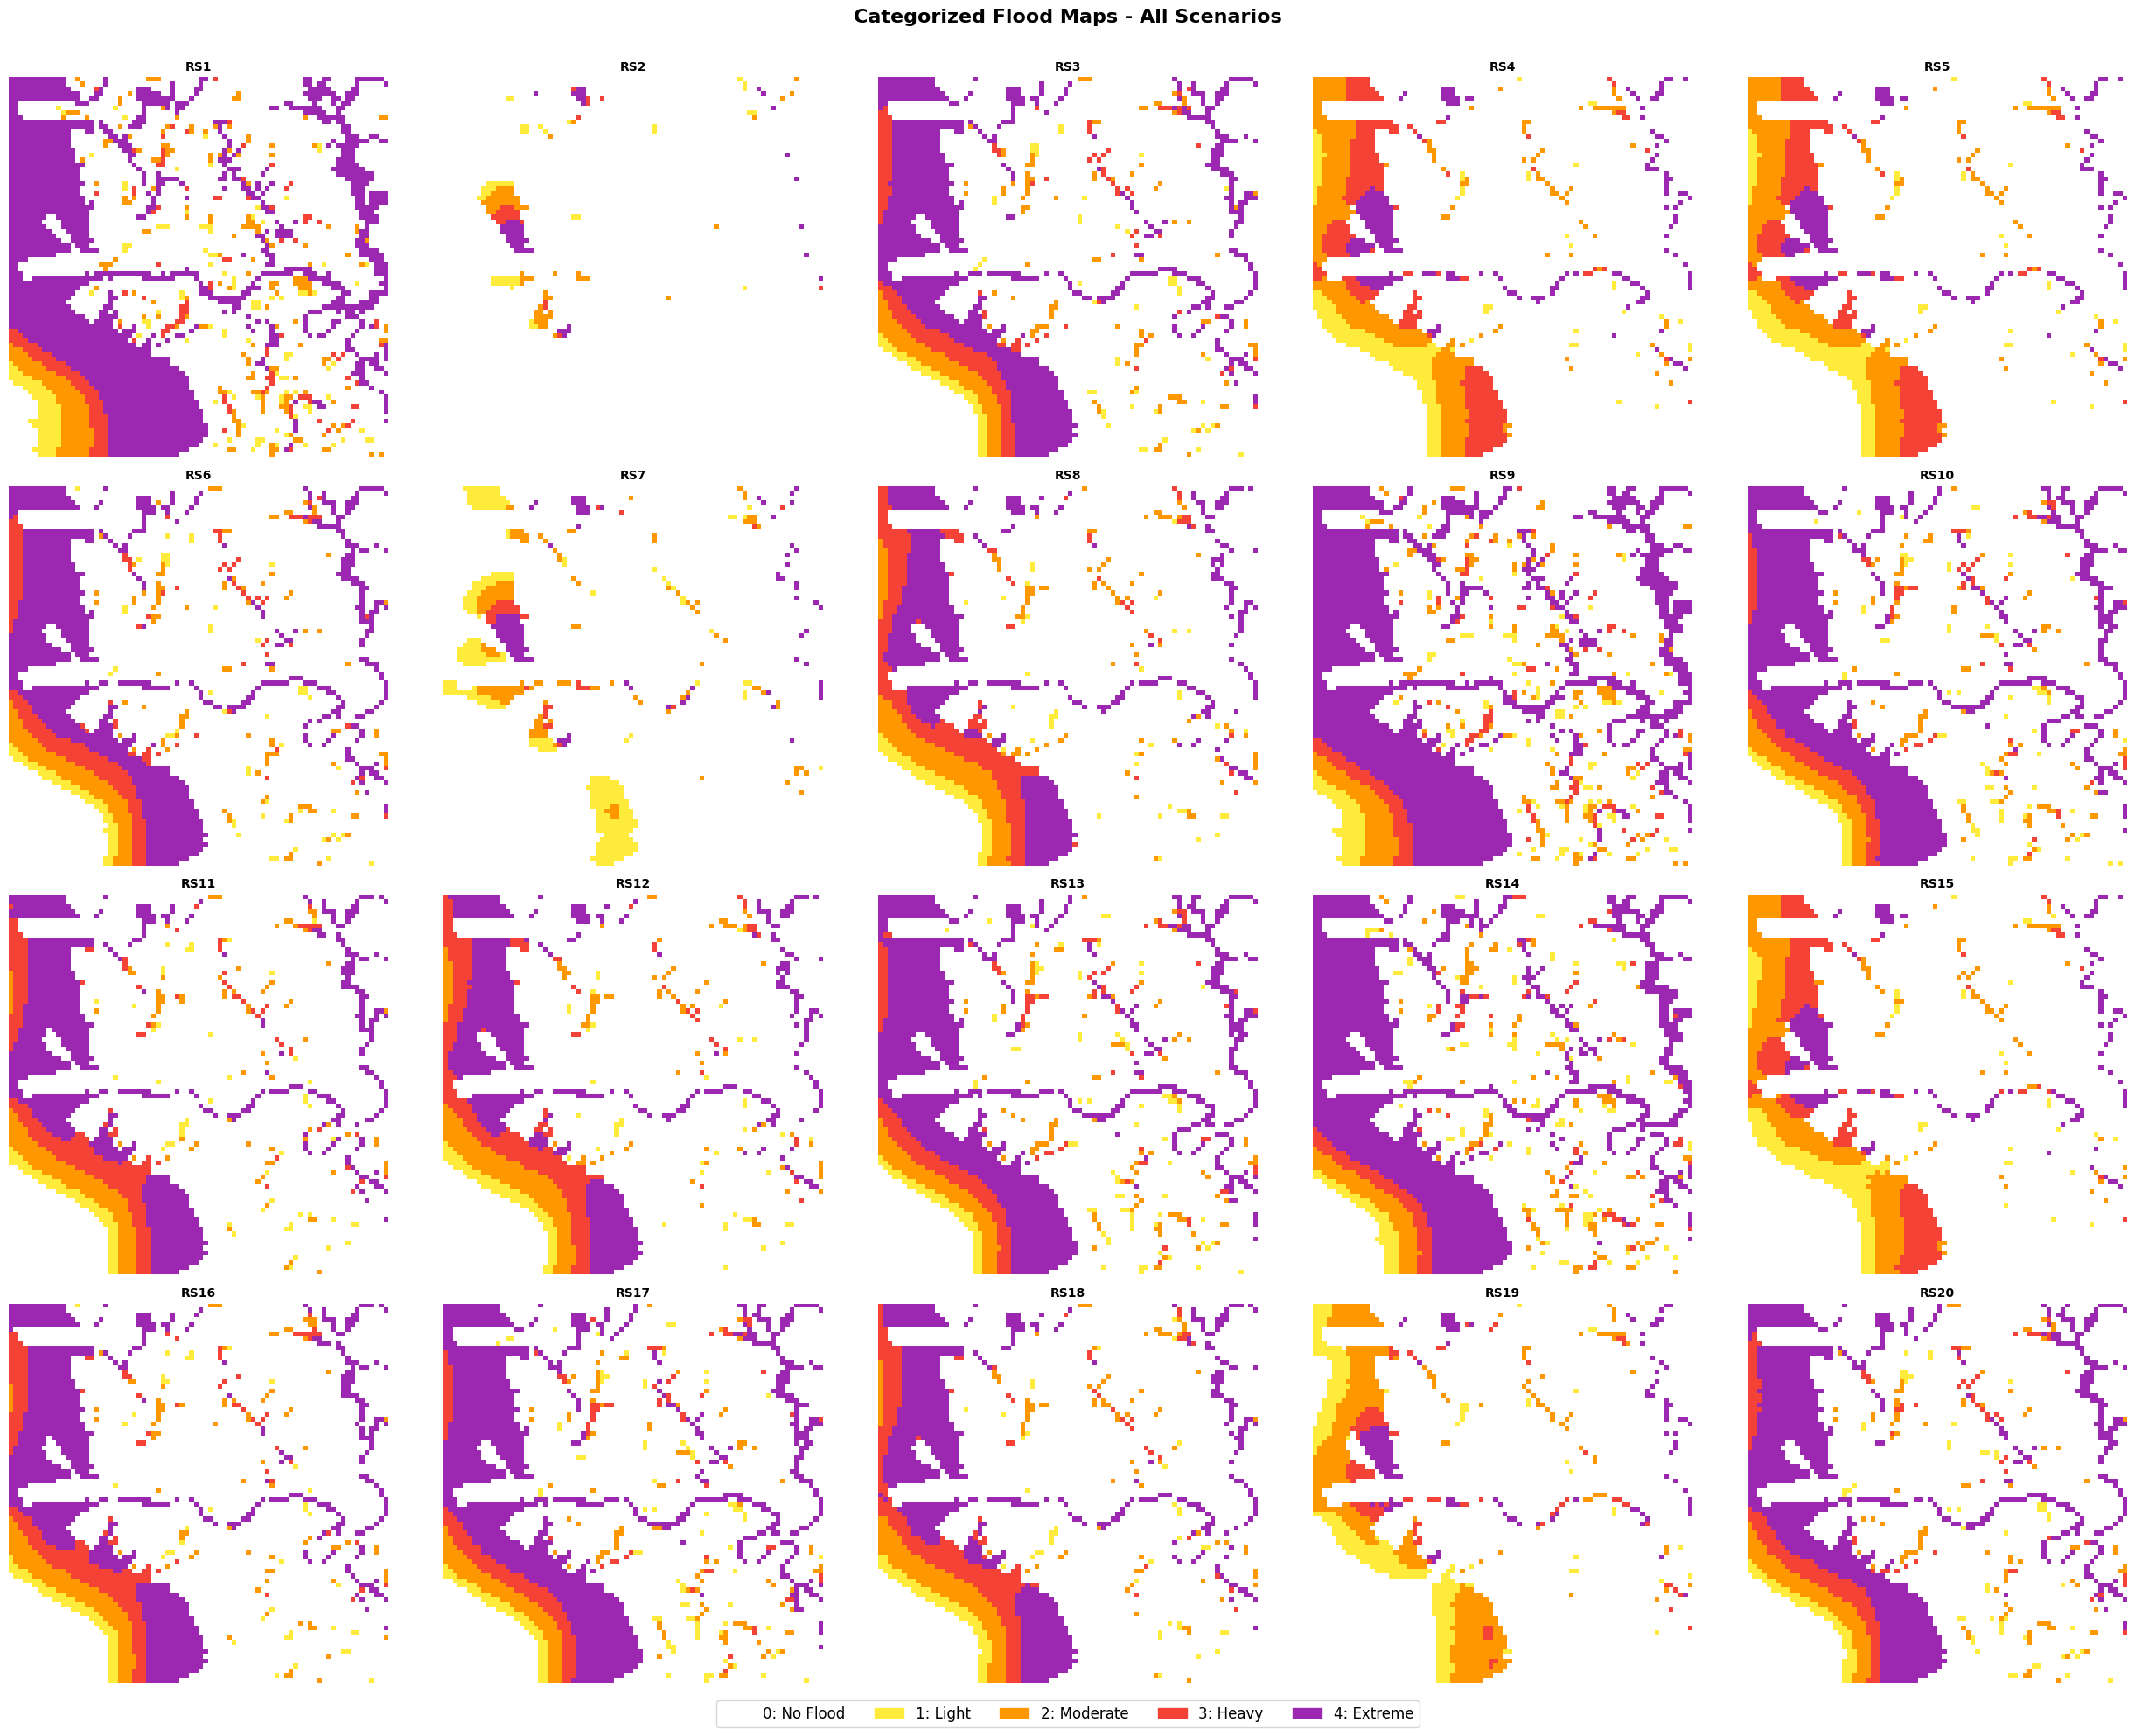

In [24]:
reconstructed_maps = []
for patch_labels, metadata in zip(flood_maps_categorized_patch, patch_metadata):
    reconstructed = reconstruct_map_from_patches(patch_labels, metadata, method='nearest')
    reconstructed_maps.append(reconstructed)

fig_all = visualize_all_categorized_maps(reconstructed_maps, scenario_ids=list(range(1, 21)), figsize=(25, 20), ncols=5)
plt.show()

In [25]:
display(flood_maps_categorized_patch)
# display(patch_metadata)

[array([4, 4, 4, ..., 0, 2, 0], shape=(6400,), dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([4, 4, 4, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([2, 2, 2, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([2, 2, 2, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([4, 4, 4, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([3, 3, 4, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([4, 4, 4, ..., 0, 2, 0], shape=(6400,), dtype=int8),
 array([4, 4, 4, ..., 0, 1, 0], shape=(6400,), dtype=int8),
 array([4, 4, 4, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([3, 4, 4, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([4, 4, 4, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([4, 4, 4, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([2, 2, 2, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([4, 4, 4, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([4, 4, 4, ..., 0, 0, 0], shape=(6

# Data Splitting Strategy

In [26]:

print("\n[1.1] Random Scenario Split")
print("-" * 70)

# Set random seed for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Total scenarios
NUM_SCENARIOS = 20
NUM_TRAIN = 15
NUM_TEST = 5

# Create list of all scenario IDs (1-20)
all_scenario_ids = list(range(1, NUM_SCENARIOS + 1))

# Randomly shuffle
random.shuffle(all_scenario_ids)

# Split into train and test
train_scenario_ids = sorted(all_scenario_ids[:NUM_TRAIN])
test_scenario_ids = sorted(all_scenario_ids[NUM_TRAIN:])

print(f"Total scenarios: {NUM_SCENARIOS}")
print(f"Training scenarios: {NUM_TRAIN}")
print(f"Test scenarios: {NUM_TEST}")

print(f"\nTrain scenario IDs: {train_scenario_ids}")
print(f"Test scenario IDs: {test_scenario_ids}")

# -----------------------------------------------------------------------------
# Organize Training Data
# -----------------------------------------------------------------------------
print("\n[1.2.1] Training Set Organization")
print("-" * 70)

train_data = {
    'scenario_ids': train_scenario_ids,
    'num_scenarios': NUM_TRAIN,
    
    'dem': dem_normalized,  
    'infiltration': infilt_normalized, 
    'landuse': landuse_normalized, 
    
    'rainfall_scenarios': [], 
    'flood_patches': [],  
}

for scenario_id in train_scenario_ids:
    idx = scenario_id - 1  # Convert to 0-indexed
    train_data['rainfall_scenarios'].append(rainfall_scenarios[idx])
    train_data['flood_patches'].append(flood_maps_categorized_patch[idx])

print(f"Training Set:")
print(f"  Scenario IDs: {train_data['scenario_ids']}")
print(f"  Number of scenarios: {train_data['num_scenarios']}")
print(f"  Spatial inputs: DEM, Infiltration, Landuse (shared)")
print(f"  Rainfall scenarios: {len(train_data['rainfall_scenarios'])} DataFrames")
print(f"  Flood patches: {len(train_data['flood_patches'])} arrays")
print(f"  Patches per scenario: {len(train_data['flood_patches'][0])}")
print(f"  Total training patches: {len(train_data['flood_patches'][0]) * train_data['num_scenarios']:,}")

# -----------------------------------------------------------------------------
# Organize Test Data
# -----------------------------------------------------------------------------
print("\n[1.2.2] Test Set Organization")
print("-" * 70)

test_data = {
    'scenario_ids': test_scenario_ids,
    'num_scenarios': NUM_TEST,
    
    'dem': dem_normalized,  
    'infiltration': infilt_normalized,  
    'landuse': landuse_normalized, 
    
    'rainfall_scenarios': [], 
    'flood_patches': [], 
}

# Extract test scenarios
for scenario_id in test_scenario_ids:
    idx = scenario_id - 1 
    test_data['rainfall_scenarios'].append(rainfall_scenarios[idx])
    test_data['flood_patches'].append(flood_maps_categorized_patch[idx])

print(f"Test Set:")
print(f"  Scenario IDs: {test_data['scenario_ids']}")
print(f"  Number of scenarios: {test_data['num_scenarios']}")
print(f"  Spatial inputs: DEM, Infiltration, Landuse (shared)")
print(f"  Rainfall scenarios: {len(test_data['rainfall_scenarios'])} DataFrames")
print(f"  Flood patches: {len(test_data['flood_patches'])} arrays")
print(f"  Patches per scenario: {len(test_data['flood_patches'][0])}")
print(f"  Total test patches: {len(test_data['flood_patches'][0]) * test_data['num_scenarios']:,}")




[1.1] Random Scenario Split
----------------------------------------------------------------------
Total scenarios: 20
Training scenarios: 15
Test scenarios: 5

Train scenario IDs: [2, 3, 5, 6, 7, 10, 11, 12, 13, 14, 15, 16, 18, 19, 20]
Test scenario IDs: [1, 4, 8, 9, 17]

[1.2.1] Training Set Organization
----------------------------------------------------------------------
Training Set:
  Scenario IDs: [2, 3, 5, 6, 7, 10, 11, 12, 13, 14, 15, 16, 18, 19, 20]
  Number of scenarios: 15
  Spatial inputs: DEM, Infiltration, Landuse (shared)
  Rainfall scenarios: 15 DataFrames
  Flood patches: 15 arrays
  Patches per scenario: 6400
  Total training patches: 96,000

[1.2.2] Test Set Organization
----------------------------------------------------------------------
Test Set:
  Scenario IDs: [1, 4, 8, 9, 17]
  Number of scenarios: 5
  Spatial inputs: DEM, Infiltration, Landuse (shared)
  Rainfall scenarios: 5 DataFrames
  Flood patches: 5 arrays
  Patches per scenario: 6400
  Total test pa

# Patch Extraction for ViT

In [27]:
print("\n[2.2] Patch Extraction Strategy")
print("-" * 70)
print("Strategy: Non-overlapping patches")

num_patches_h = 320 // PATCH_SIZE
num_patches_w = 320 // PATCH_SIZE
total_patches = num_patches_h * num_patches_w

def extract_patches_2d(image: np.ndarray, patch_size: int) -> np.ndarray:
    h, w = image.shape
    assert h % patch_size == 0 and w % patch_size == 0, "Image size must be divisible by patch_size"
    
    num_patches_h = h // patch_size
    num_patches_w = w // patch_size
    
    # Reshape to extract patches
    patches = image.reshape(num_patches_h, patch_size, num_patches_w, patch_size)
    patches = patches.transpose(0, 2, 1, 3)  # (num_h, num_w, patch_size, patch_size)
    patches = patches.reshape(-1, patch_size, patch_size)  # (num_patches, patch_size, patch_size)
    
    return patches


[2.2] Patch Extraction Strategy
----------------------------------------------------------------------
Strategy: Non-overlapping patches


In [28]:
print("\n[2.3] Stacking Spatial Inputs")
print("-" * 70)

def extract_spatial_patches(dem: np.ndarray, infiltration: np.ndarray, landuse: np.ndarray, patch_size: int) -> np.ndarray:
    # Extract patches from each layer
    dem_patches = extract_patches_2d(dem, patch_size)
    infilt_patches = extract_patches_2d(infiltration, patch_size)
    landuse_patches = extract_patches_2d(landuse, patch_size)
    
    # Stack as channels (num_patches, 3, patch_size, patch_size)
    stacked_patches = np.stack([dem_patches, infilt_patches, landuse_patches], axis=1)
    return stacked_patches

# Extract spatial patches (these are shared across all scenarios)
spatial_patches = extract_spatial_patches(dem_normalized, infilt_normalized, landuse_normalized, PATCH_SIZE)
print(f"Spatial patches extracted:")
print(f"  Shape: {spatial_patches.shape}")
print(f"  Expected: ({total_patches}, 3, {PATCH_SIZE}, {PATCH_SIZE})")


[2.3] Stacking Spatial Inputs
----------------------------------------------------------------------
Spatial patches extracted:
  Shape: (6400, 3, 4, 4)
  Expected: (6400, 3, 4, 4)


In [29]:
print("\n[2.4] Handling Rainfall: Strategy 1 (Rainfall as Temporal Sequence)")
print("-" * 70)
print("Approach: Rainfall temporal sequence will be embedded as tokens")
print("Implementation: Each 13-timestep sequence becomes temporal tokens in ViT")

def extract_rainfall_sequences(rainfall_scenarios: List, 
                               scenario_ids: List[int],
                               normalize: bool = True) -> np.ndarray:
    sequences = []
    
    for scenario_id in scenario_ids:
        idx = scenario_id - 1  # Convert to 0-indexed
        scenario_df = rainfall_scenarios[idx]
        
        # Extract intensity column
        intensity_col = 'intensity_mmhr'
        if intensity_col not in scenario_df.columns:
            # Try alternative names
            for col in ['rainfall', 'Rainfall', 'rain', 'intensity']:
                if col in scenario_df.columns:
                    intensity_col = col
                    break
        
        # Get full intensity sequence (all 13 timesteps)
        intensity_sequence = scenario_df[intensity_col].values
        sequences.append(intensity_sequence)
    
    sequences = np.array(sequences, dtype=np.float32)  # Shape: (num_scenarios, 13)
    
    if normalize:
        # Normalize to [0, 1] range using global max intensity
        max_intensity = sequences.max()
        sequences = sequences / max_intensity
        print(f"  Normalized by max intensity: {max_intensity:.2f} mm/hr")
    
    return sequences, max_intensity if normalize else None


# Extract temporal sequences for train and test
print("\nExtracting temporal rainfall sequences...")

train_rainfall_sequences, max_intensity_train = extract_rainfall_sequences(
    rainfall_scenarios, 
    train_scenario_ids,
    normalize=True
)

# Use same max_intensity for test set 
test_rainfall_sequences_raw = extract_rainfall_sequences(
    rainfall_scenarios,
    test_scenario_ids,
    normalize=False
)[0]
test_rainfall_sequences = test_rainfall_sequences_raw / max_intensity_train

print(f"\nTrain rainfall sequences:")
print(f"  Shape: {train_rainfall_sequences.shape}")
print(f"  Each scenario: 13 timesteps")
print(f"  Range: [{train_rainfall_sequences.min():.4f}, {train_rainfall_sequences.max():.4f}]")
print(f"\n  Example (Scenario {train_scenario_ids[0]}):")
print(f"    Timesteps: {train_rainfall_sequences[0]}")

print(f"\nTest rainfall sequences:")
print(f"  Shape: {test_rainfall_sequences.shape}")
print(f"  Range: [{test_rainfall_sequences.min():.4f}, {test_rainfall_sequences.max():.4f}]")
print(f"\n  Example (Scenario {test_scenario_ids[0]}):")
print(f"    Timesteps: {test_rainfall_sequences[0]}")


[2.4] Handling Rainfall: Strategy 1 (Rainfall as Temporal Sequence)
----------------------------------------------------------------------
Approach: Rainfall temporal sequence will be embedded as tokens
Implementation: Each 13-timestep sequence becomes temporal tokens in ViT

Extracting temporal rainfall sequences...
  Normalized by max intensity: 130.92 mm/hr

Train rainfall sequences:
  Shape: (15, 13)
  Each scenario: 13 timesteps
  Range: [0.0000, 1.0000]

  Example (Scenario 2):
    Timesteps: [4.7907930e-02 9.9883653e-02 1.1155279e-01 1.0008978e-01 7.8001611e-02
 5.3785115e-02 3.2584425e-02 1.6848346e-02 6.9877445e-03 2.0329622e-03
 2.9120885e-04 3.9338097e-06 0.0000000e+00]

Test rainfall sequences:
  Shape: (5, 13)
  Range: [0.0000, 1.4502]

  Example (Scenario 1):
    Timesteps: [3.0341685e-01 6.3259649e-01 7.0650101e-01 6.3390195e-01 4.9401018e-01
 3.4063905e-01 2.0636804e-01 1.0670620e-01 4.4255726e-02 1.2875436e-02
 1.8443074e-03 2.4939589e-05 0.0000000e+00]


In [30]:
print("\n[2.5] Ground Truth Labels Per Patch")
print("-" * 70)
print(f"Each scenario has {len(flood_maps_categorized_patch[0])} patch labels (0-4)")

# Organize labels by split
train_patch_labels = [flood_maps_categorized_patch[sid - 1] for sid in train_scenario_ids]
test_patch_labels = [flood_maps_categorized_patch[sid - 1] for sid in test_scenario_ids]



[2.5] Ground Truth Labels Per Patch
----------------------------------------------------------------------
Each scenario has 6400 patch labels (0-4)


In [31]:
print("\n[2.6] Creating Complete Dataset Structure (with Temporal Sequences)")
print("-" * 70)

def create_patch_dataset_with_sequences(spatial_patches: np.ndarray, 
                                       scenario_ids: List[int], 
                                       rainfall_sequences: np.ndarray, 
                                       patch_labels: List[np.ndarray]) -> Dict:
    num_scenarios = len(scenario_ids)
    patches_per_scenario = spatial_patches.shape[0]
    total_samples = num_scenarios * patches_per_scenario
    
    # Spatial patches: repeat for each scenario
    # Shape: (num_scenarios, num_patches, 3, H, W)
    all_spatial_patches = np.tile(spatial_patches[np.newaxis, ...], (num_scenarios, 1, 1, 1, 1))
    
    # Rainfall sequences: repeat for each patch in scenario
    # Shape: (num_scenarios, num_patches, 13)
    all_rainfall_sequences = np.tile(rainfall_sequences[:, np.newaxis, :], (1, patches_per_scenario, 1))
    
    # Labels: stack
    # Shape: (num_scenarios, num_patches)
    all_patch_labels = np.stack(patch_labels, axis=0)
    
    dataset = {
        'spatial_patches': all_spatial_patches,      # (num_scenarios, num_patches, 3, H, W)
        'rainfall_sequences': all_rainfall_sequences, # (num_scenarios, num_patches, 13)
        'labels': all_patch_labels,                   # (num_scenarios, num_patches)
        'scenario_ids': scenario_ids,
        'num_scenarios': num_scenarios,
        'patches_per_scenario': patches_per_scenario,
        'total_samples': total_samples
    }
    
    return dataset


# Create training dataset
print("\nCreating training dataset...")
train_dataset = create_patch_dataset_with_sequences(
    spatial_patches, 
    train_scenario_ids, 
    train_rainfall_sequences,  
    train_patch_labels
)

print(f"Training dataset:")
print(f"  Spatial patches: {train_dataset['spatial_patches'].shape}")
print(f"  Rainfall sequences: {train_dataset['rainfall_sequences'].shape}")  
print(f"  Labels: {train_dataset['labels'].shape}")
print(f"  Total samples: {train_dataset['total_samples']:,}")

# Create test dataset
print("\nCreating test dataset...")
test_dataset = create_patch_dataset_with_sequences(
    spatial_patches, 
    test_scenario_ids, 
    test_rainfall_sequences,  
    test_patch_labels
)

print(f"Test dataset:")
print(f"  Spatial patches: {test_dataset['spatial_patches'].shape}")
print(f"  Rainfall sequences: {test_dataset['rainfall_sequences'].shape}") 
print(f"  Labels: {test_dataset['labels'].shape}")
print(f"  Total samples: {test_dataset['total_samples']:,}")


[2.6] Creating Complete Dataset Structure (with Temporal Sequences)
----------------------------------------------------------------------

Creating training dataset...
Training dataset:
  Spatial patches: (15, 6400, 3, 4, 4)
  Rainfall sequences: (15, 6400, 13)
  Labels: (15, 6400)
  Total samples: 96,000

Creating test dataset...
Test dataset:
  Spatial patches: (5, 6400, 3, 4, 4)
  Rainfall sequences: (5, 6400, 13)
  Labels: (5, 6400)
  Total samples: 32,000


In [32]:
print("\n" + "="*70)
print("PHASE 3: DATALOADER SETUP (with Temporal Sequences)")
print("="*70)

print("\n[3.1] Creating PyTorch Dataset Class")
print("-" * 70)

class FloodPatchDataset(Dataset):
    def __init__(self, dataset_dict: Dict, transform=None):
        self.spatial_patches = dataset_dict['spatial_patches']      # (num_scenarios, num_patches, 3, H, W)
        self.rainfall_sequences = dataset_dict['rainfall_sequences'] # (num_scenarios, num_patches, 13)
        self.labels = dataset_dict['labels']                         # (num_scenarios, num_patches)
        
        self.num_scenarios = dataset_dict['num_scenarios']
        self.patches_per_scenario = dataset_dict['patches_per_scenario']
        self.total_samples = dataset_dict['total_samples']
        self.scenario_ids = dataset_dict['scenario_ids']
        
        self.transform = transform
        
        # Flatten arrays for easier indexing
        # Spatial: (total_samples, 3, H, W)
        self.spatial_patches_flat = self.spatial_patches.reshape(
            self.total_samples, *self.spatial_patches.shape[2:]
        )
        
        # Rainfall sequences: (total_samples, 13)
        self.rainfall_sequences_flat = self.rainfall_sequences.reshape(
            self.total_samples, -1
        )
        
        # Labels: (total_samples,)
        self.labels_flat = self.labels.flatten()
        
        print(f"FloodPatchDataset initialized:")
        print(f"  Total samples: {self.total_samples:,}")
        print(f"  Scenarios: {self.num_scenarios}")
        print(f"  Patches per scenario: {self.patches_per_scenario}")
        print(f"  Spatial patch shape: {self.spatial_patches_flat.shape[1:]}")
        print(f"  Rainfall sequence shape: {self.rainfall_sequences_flat.shape[1:]}")
        
    def __len__(self) -> int:
        return self.total_samples
    
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        # Get spatial patch (3, H, W)
        spatial_patch = self.spatial_patches_flat[idx]
        
        # Get rainfall sequence (13,)
        rainfall_seq = self.rainfall_sequences_flat[idx]
        
        # Get label (scalar)
        label = self.labels_flat[idx]
        
        # Convert to PyTorch tensors
        spatial_patch = torch.from_numpy(spatial_patch).float()
        rainfall_seq = torch.from_numpy(rainfall_seq).float() 
        label = torch.tensor(label, dtype=torch.long)
        
        # Apply transform if provided
        if self.transform:
            spatial_patch = self.transform(spatial_patch)
        
        return spatial_patch, rainfall_seq, label
    
    def get_scenario_id(self, idx: int) -> int:
        scenario_idx = idx // self.patches_per_scenario
        return self.scenario_ids[scenario_idx]


print("✓ FloodPatchDataset class defined")

# Create PyTorch datasets
train_pytorch_dataset = FloodPatchDataset(train_dataset)
test_pytorch_dataset = FloodPatchDataset(test_dataset)

print(f"\n✓ PyTorch datasets created:")
print(f"  Training: {len(train_pytorch_dataset):,} samples")
print(f"  Test: {len(test_pytorch_dataset):,} samples")

# Test dataset
print("\n[3.2] Evaluate Dataset")
print("-" * 70)
sample_spatial, sample_rainfall, sample_label = train_pytorch_dataset[0]
print(f"Sample 0:")
print(f"  Spatial patch shape: {sample_spatial.shape}")
print(f"  Rainfall sequence shape: {sample_rainfall.shape}")  # Should be (13,)
print(f"  Rainfall sequence: {sample_rainfall}")
print(f"  Label: {sample_label.item()} ({FLOOD_CLASSES[sample_label.item()]['name']})")
print(f"  Scenario ID: {train_pytorch_dataset.get_scenario_id(0)}")


PHASE 3: DATALOADER SETUP (with Temporal Sequences)

[3.1] Creating PyTorch Dataset Class
----------------------------------------------------------------------
✓ FloodPatchDataset class defined
FloodPatchDataset initialized:
  Total samples: 96,000
  Scenarios: 15
  Patches per scenario: 6400
  Spatial patch shape: (3, 4, 4)
  Rainfall sequence shape: (13,)
FloodPatchDataset initialized:
  Total samples: 32,000
  Scenarios: 5
  Patches per scenario: 6400
  Spatial patch shape: (3, 4, 4)
  Rainfall sequence shape: (13,)

✓ PyTorch datasets created:
  Training: 96,000 samples
  Test: 32,000 samples

[3.2] Evaluate Dataset
----------------------------------------------------------------------
Sample 0:
  Spatial patch shape: torch.Size([3, 4, 4])
  Rainfall sequence shape: torch.Size([13])
  Rainfall sequence: tensor([4.7908e-02, 9.9884e-02, 1.1155e-01, 1.0009e-01, 7.8002e-02, 5.3785e-02,
        3.2584e-02, 1.6848e-02, 6.9877e-03, 2.0330e-03, 2.9121e-04, 3.9338e-06,
        0.0000e+00]

# ViT Architecture

In [33]:
print("\n" + "="*70)
print("PHASE 4: VIT ARCHITECTURE DESIGN (WITH TEMPORAL RAINFALL)")
print("="*70)

# Model hyperparameters
IN_CHANNELS = 3       
PATCH_SIZE = 4       
NUM_CLASSES = 5      
NUM_TIMESTEPS = 13   

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

from vit_architecture import ViTFloodClassifier, get_model_summary
from model_config import (create_small_model, create_small_regularized_model, compare_all_configurations, print_model_details)

# Compare all available configurations
compare_all_configurations()

print("\n" + "="*70)
print("CREATING MODEL")
print("="*70)

model = create_small_regularized_model()
model = model.to(device)

# Print summary
print(get_model_summary(model))

# Print detailed architecture
print_model_details(model)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


PHASE 4: VIT ARCHITECTURE DESIGN (WITH TEMPORAL RAINFALL)
Device: cpu

MODEL CONFIGURATION COMPARISON (WITH TEMPORAL RAINFALL)
Dataset: 96,000 training samples
Patch size: 4x4
Input channels: 3 (DEM, Infiltration, Landuse)
Rainfall timesteps: 13 (temporal sequence)
Output classes: 5

Config                         Params       Embed    Layers   Heads    Rain Method  Dropout   
------------------------------------------------------------------------------------------
Tiny ViT (Temporal)               883,333  128      4        4        conv         0.10      
Compact ViT (Temporal)          2,791,941  192      6        6        conv         0.10      
Small ViT (Temporal)            4,902,021  256      6        8        conv         0.10      
Small ViT (Reg, Temp)           4,902,021  256      6        8        conv         0.25      
Medium ViT (Temporal)          14,465,157  384      8        8        conv         0.15      
Base ViT (Temporal)            38,236,805  512      12    

In [34]:
print()
print(model)


ViTFloodClassifier(
  (patch_embedding): PatchEmbedding(
    (projection): Conv2d(3, 256, kernel_size=(4, 4), stride=(4, 4))
  )
  (rainfall_embedding): RainfallSequenceEmbedding(
    (temporal_encoder): Sequential(
      (0): Conv1d(1, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): GELU(approximate='none')
      (2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (3): GELU(approximate='none')
      (4): AdaptiveAvgPool1d(output_size=1)
      (5): Flatten(start_dim=1, end_dim=-1)
    )
    (projection): Linear(in_features=128, out_features=256, bias=True)
  )
  (pos_encoding): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerBlock(
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_fea

# Training Setup

In [ ]:
patches_per_scenario = 6400
scenario_to_samples = {}
for idx, scenario_id in enumerate(train_scenario_ids):
    start = idx * patches_per_scenario
    end = start + patches_per_scenario
    scenario_to_samples[scenario_id] = list(range(start, end))

fold_histories, best_fold = train_kfold(
    model_factory=create_small_model,
    full_dataset=train_pytorch_dataset,
    scenario_to_samples=scenario_to_samples,
    batch_size=32,
    num_epochs=10,
    device=device,
    use_smote=False
)


K-FOLD CROSS-VALIDATION SETUP
SMOTE: Disabled

Fold 1: Train on 10 scenarios, Validate on 5 scenarios
  Train: [3, 5, 6, 7, 11, 12, 13, 15, 18, 20]
  Val:   [2, 10, 14, 16, 19]

Fold 2: Train on 10 scenarios, Validate on 5 scenarios
  Train: [2, 6, 10, 11, 12, 14, 15, 16, 18, 19]
  Val:   [3, 5, 7, 13, 20]

Fold 3: Train on 10 scenarios, Validate on 5 scenarios
  Train: [2, 3, 5, 7, 10, 13, 14, 16, 19, 20]
  Val:   [6, 11, 12, 15, 18]

Fold 1: 64,000 train samples, 32,000 val samples

FOLD 1/3
[train_one_fold] Extracting labels from dataset...
[train_one_fold] Extracting 64000 labels from Subset...
[train_one_fold] Labels extracted in 1.1s

Class distribution:
  Class 0: 48,101 samples (75.16%) - weight: 0.266
  Class 1:  1,725 samples ( 2.70%) - weight: 7.420
  Class 2:  3,146 samples ( 4.92%) - weight: 4.069
  Class 3:  3,040 samples ( 4.75%) - weight: 4.211
  Class 4:  7,988 samples (12.48%) - weight: 1.602
[train_one_fold] Setting up training components...
[train_one_fold] Trainin

# Testing

In [ ]:
print("\n" + "="*70)
print("PHASE 7: TEST EVALUATION")
print("="*70)

# -----------------------------------------------------------------------------
# 7.1 Load Best Model
# -----------------------------------------------------------------------------

print("\n[7.1] Loading best model from training...")
best_fold_idx = best_fold  

model = create_small_model()
model_path = f'./checkpoints/fold_{best_fold_idx + 1}/best_model.pt'
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

print(f"✓ Loaded model from Fold {best_fold_idx + 1}")
print(f"  Model path: {model_path}")


In [ ]:
# -----------------------------------------------------------------------------
# 7.2 Prepare Ground Truth Maps
# -----------------------------------------------------------------------------

print("\n[7.2] Preparing ground truth maps for test scenarios...")

ground_truth_maps = {}

for scenario_id in test_scenario_ids:
    # Get the index in test_dataset arrays
    scenario_idx = test_scenario_ids.index(scenario_id)
    
    # Extract ground truth from test_dataset
    # test_dataset['labels'] has shape (num_test_scenarios, 6400)
    ground_truth_patches = test_dataset['labels'][scenario_idx]  # (6400,)
    
    # Reconstruct to 320×320 map
    from testing import reconstruct_test_map_from_patches
    ground_truth_map = reconstruct_test_map_from_patches(ground_truth_patches)
    
    ground_truth_maps[scenario_id] = ground_truth_map
    
    print(f"  Scenario {scenario_id}: Ground truth shape {ground_truth_map.shape}")

print(f"✓ Prepared {len(ground_truth_maps)} ground truth maps")


In [ ]:
# -----------------------------------------------------------------------------
# 7.3 Evaluate All Test Scenarios
# -----------------------------------------------------------------------------

print("\n[7.3] Evaluating all test scenarios...")

all_results, all_predictions = evaluate_test_scenarios(
    model=model,
    test_dataset=test_pytorch_dataset,
    test_scenario_ids=test_scenario_ids,
    ground_truth_maps=ground_truth_maps,
    device=device,
    save_dir='./results'
)

# -----------------------------------------------------------------------------
# 7.4 Visualize Results
# -----------------------------------------------------------------------------

print("\n[7.4] Generating visualizations...")

results_dir = Path('./results')
results_dir.mkdir(parents=True, exist_ok=True)

for scenario_id in test_scenario_ids:
    print(f"\nVisualizing Scenario {scenario_id}...")
    
    # Confusion matrix
    plot_confusion_matrix(
        metrics=all_results[scenario_id],
        scenario_id=scenario_id,
        save_path=results_dir / f'confusion_matrix_scenario_{scenario_id}.png'
    )
    
    # Ground truth vs prediction
    plot_scenario_comparison(
        scenario_id=scenario_id,
        ground_truth_map=ground_truth_maps[scenario_id],
        predicted_map=all_predictions[scenario_id],
        save_path=results_dir / f'comparison_scenario_{scenario_id}.png'
    )

print("\n✓ All visualizations generated!")

# -----------------------------------------------------------------------------
# 7.5 Print Detailed Results
# -----------------------------------------------------------------------------

print("\n" + "="*70)
print("DETAILED TEST RESULTS")
print("="*70)

for scenario_id in test_scenario_ids:
    metrics = all_results[scenario_id]
    
    print(f"\n{'='*70}")
    print(f"SCENARIO {scenario_id}")
    print(f"{'='*70}")
    print(f"Overall Accuracy: {metrics['accuracy']:.4f}")
    print(f"Mean IoU (mIoU):  {metrics['mean_iou']:.4f}")
    
    print("\nPer-Class Metrics:")
    print(f"{'Class':<10} {'IoU':<10} {'Precision':<12} {'Recall':<10} {'F1-Score':<10} {'Support':<10}")
    print("-" * 70)
    
    for class_id in range(5):
        iou = metrics['iou_per_class'][class_id]
        precision = metrics['precision_per_class'][class_id]
        recall = metrics['recall_per_class'][class_id]
        f1 = metrics['f1_per_class'][class_id]
        support = metrics['support_per_class'][class_id]
        
        print(f"{class_id:<10} {iou:<10.4f} {precision:<12.4f} {recall:<10.4f} {f1:<10.4f} {support:<10}")

print("\n" + "="*70)
print("TEST EVALUATION COMPLETE!")
print("="*70)

# Pipeline Checklist for Flood Susceptibility Mapping with ViT

## 📋 Complete Pipeline Overview

---

## **PHASE 1: Data Splitting Strategy** 

### **1.1 Scenario-Based Random Split**
- [ ] Set random seed for reproducibility
- [ ] Randomly select 15 scenarios for training (e.g., scenarios [2, 5, 7, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 1])
- [ ] Remaining 5 scenarios for testing (e.g., [3, 4, 6, 8, 12])
- [ ] Document which scenarios belong to train/test
- [ ] Verify no overlap between train and test scenarios

### **1.2 Data Organization Per Split**
**Training Set:**
- [ ] DEM (normalized) - shape: (320, 320)
- [ ] Infiltration (normalized) - shape: (320, 320)
- [ ] Landuse (normalized) - shape: (320, 320)
- [ ] 15 rainfall scenarios (temporal input)
- [ ] 15 categorized flood maps (ground truth labels, classes 0-4)

**Test Set:**
- [ ] Same spatial inputs (DEM, Infiltration, Landuse) - same pixels
- [ ] 5 rainfall scenarios (temporal input)
- [ ] 5 categorized flood maps (ground truth labels)

### **1.3 Key Consideration**
- [ ] **Question to resolve:** Do all scenarios share the same spatial inputs (DEM, Infiltration, Landuse)?
  - ANSWER: YES: Spatial inputs are constant across all scenarios

---

## **PHASE 2: Patch Extraction for ViT** 🎯

### **2.1 Patch Size Decision**
- [ ] Choose patch size: PATCH_SIZE = 4

### **2.2 Patch Extraction Strategy**
- [ ] **Option A: Non-overlapping patches** (standard for ViT)
  - Extract patches on a regular grid
  - Example: 320×320 image with PATCH_SIZE×PATCH_SIZE patches

### **2.3 Stacking Spatial Inputs**
- [ ] Stack DEM + Infiltration + Landuse into 3-channel input
  - Input tensor shape per patch: `[3, patch_size, patch_size]`
  - 3 channels analogous to RGB in images

### **2.4 Handling Rainfall (Temporal Input)**
- [ ] **Strategy 1: Rainfall as Additional Token**
  - Embed rainfall value into same dimension as patch embeddings
  - Prepend to sequence: `[rainfall_token, patch_1, patch_2, ..., patch_N]`
  
- [ ] **Strategy 2: Rainfall as Conditional Input**
  - Add rainfall embedding to all patch embeddings
  - Similar to positional encoding but for temporal condition
  
- [ ] **Strategy 3: Rainfall as Extra Channel**
  - Broadcast rainfall value across spatial dimensions
  - Stack as 4th channel: `[DEM, Infiltration, Landuse, Rainfall]`
  - Shape: `[4, patch_size, patch_size]`

### **2.5 Ground Truth Labels Per Patch**
- [ ] For each patch, extract corresponding label patch from categorized flood map -> 

---

## **PHASE 3: Dataset Creation** 📦

### **3.1 Training Dataset Structure**
For each training scenario (15 total):
- [ ] Extract all patches from stacked spatial inputs
- [ ] Associate each patch with rainfall value for that scenario
- [ ] Extract corresponding label patches from categorized flood map
- [ ] Result: ~400 patches × 15 scenarios = **6,000 training samples** (if 16×16 patches)

### **3.2 Test Dataset Structure**
For each test scenario (5 total):
- [ ] Extract patches from same spatial inputs
- [ ] Associate with rainfall values for test scenarios
- [ ] Extract label patches
- [ ] Result: ~400 patches × 5 scenarios = **2,000 test samples**


### **3.4 Dataloader Setup**
- [ ] Create PyTorch Dataset class
- [ ] Implement `__getitem__`: Return (stacked_patch, rainfall_value, label_patch)
- [ ] Create DataLoader with batch_size (e.g., 32, 64, 128)
- [ ] Shuffle training data, don't shuffle test data

---

## **PHASE 4: ViT Architecture Design** 🏗️

### **4.1 Input Processing**
- [ ] **Patch Embedding Layer**
  - Input: `[batch, 3_or_4_channels, patch_size, patch_size]`
  - Output: `[batch, num_patches, embed_dim]`
  - Use Conv2d with kernel=patch_size, stride=patch_size
  
- [ ] **Rainfall Embedding** (if using token/conditional approach)
  - Input: `[batch, 1]` (scalar rainfall value)
  - Output: `[batch, embed_dim]`
  - Use MLP: Linear(1, 128) → GELU → Linear(128, embed_dim)

### **4.2 Position Encoding**
- [ ] Add learnable or fixed positional embeddings to patch tokens
- [ ] Shape: `[1, num_patches, embed_dim]`
- [ ] Helps model understand spatial relationships

### **4.3 Transformer Encoder**
- [ ] Stack multiple transformer blocks (e.g., 6-12 layers)
- [ ] Each block contains:
  - Multi-head self-attention (e.g., 8 or 12 heads)
  - Layer normalization
  - Feed-forward network (MLP)
  - Residual connections
  - Dropout for regularization

### **4.4 Decoder Head**
**For Per-Patch Classification (Majority Label):**
- [ ] Global average pooling or use [CLS] token
- [ ] MLP classifier: Linear → ReLU → Dropout → Linear(embed_dim, num_classes=5)
- [ ] Output: `[batch, 5]` (class probabilities)

**For Dense Per-Pixel Prediction:**
- [ ] Reshape patch tokens back to spatial grid
- [ ] Upsample to original patch resolution
- [ ] Final conv layer: Conv2d(embed_dim, num_classes=5)
- [ ] Output: `[batch, 5, patch_size, patch_size]`

### **4.5 Rainfall Integration Point**
- [ ] **token approach:** Prepend rainfall token before transformer

---

## **PHASE 5: Model Configuration** ⚙️

### **5.1 Architecture Hyperparameters**
- [ ] **Patch size:** 16×16 or 32×32 (start with 16×16)
- [ ] **Embedding dimension:** 384 (small), 768 (base), or 1024 (large)
- [ ] **Number of transformer layers:** 6 (small), 12 (base), or 24 (large)
- [ ] **Number of attention heads:** 6, 8, or 12
- [ ] **MLP ratio:** 4 (standard)
- [ ] **Dropout rate:** 0.1

### **5.2 Model Size Recommendation**
**For your dataset size (6K training samples):**
- [ ] Start with **Small ViT:**
  - Patch: 16×16, Embed: 384, Depth: 6, Heads: 6
  - ~10M parameters
  
- [ ] If overfitting: Reduce to:
  - Patch: 32×32, Embed: 256, Depth: 4, Heads: 4
  
- [ ] If underfitting: Increase to:
  - Patch: 16×16, Embed: 768, Depth: 12, Heads: 12 (Base ViT)

---

## **PHASE 6: Training Setup** 🎓

### **6.1 Loss Function**
**For Multi-Class Classification (5 classes):**
- [ ] **Cross-Entropy Loss** (standard)
  - Handles class imbalance via weighted loss
  - Calculate class weights from training set distribution
  
- [ ] **Focal Loss** (optional, if severe class imbalance)
  - Focuses on hard-to-classify examples
  
- [ ] **Combined Loss** (optional)
  - Cross-Entropy + Dice Loss (for spatial consistency)

### **6.2 Class Weighting**
- [ ] Calculate inverse frequency weights from training set
- [ ] Apply to loss function to handle imbalance (e.g., "No Flood" class may dominate)

### **6.3 Optimizer**
- [ ] **AdamW** (recommended for ViT)
  - Learning rate: 1e-4 to 5e-4
  - Weight decay: 0.05 to 0.1
  - Betas: (0.9, 0.999)

### **6.4 Learning Rate Schedule**
- [ ] **Warmup** for first 5-10% of training
  - Linear increase from 0 to peak LR
  
- [ ] **Decay** after warmup
  - Cosine annealing (smooth decay to 0)
  - Or step decay
  - Or ReduceLROnPlateau (based on validation loss)

### **6.5 Training Strategy**
- [ ] **Epochs:** 100-300 with early stopping
- [ ] **Batch size:** 32, 64, or 128 (depends on GPU memory)
- [ ] **Gradient clipping:** Max norm = 1.0
- [ ] **Mixed precision:** FP16 (saves memory, faster training)
- [ ] **Early stopping:** Patience = 20-30 epochs

### **6.6 Validation Strategy**
- [ ] **Option B:** Use k-fold cross-validation on scenarios
  - Split 15 training scenarios into 3 folds
  - Train on 10, validate on 5, repeat 3 times

### **6.7 Regularization**
- [ ] Dropout in transformer: 0.1
- [ ] Stochastic depth (drop path): 0.1
- [ ] Data augmentation (geometric transforms)
- [ ] Weight decay: 0.05

---

## **PHASE 7: Evaluation Metrics** 📊

### **7.1 Per-Patch Metrics**
- [ ] **Accuracy:** Overall classification accuracy
- [ ] **Per-Class Accuracy:** Accuracy for each of 5 classes
- [ ] **Precision, Recall, F1-Score** per class
- [ ] **Confusion Matrix:** See which classes are confused

### **7.2 Scenario-Level Metrics**
- [ ] For each of 5 test scenarios:
  - Reconstruct full 320×320 prediction map from patches
  - Compare against full ground truth categorized map
  - Calculate IoU, F1, accuracy

### **7.3 Class-Specific Metrics**
- [ ] **Class 0 (No Flood):** Precision/Recall (avoid false alarms)
- [ ] **Classes 3-4 (Heavy/Extreme):** Recall (critical to detect severe flooding)
- [ ] **Macro-averaged F1:** Treats all classes equally
- [ ] **Weighted F1:** Weighted by class frequency

### **7.4 Spatial Metrics**
- [ ] **IoU (Intersection over Union)** for each class
- [ ] **Critical Success Index (CSI)** for flooding detection
- [ ] Visualize prediction maps vs ground truth

---

## **PHASE 8: Inference & Deployment** 🚀

### **8.1 Prediction Pipeline**
- [ ] Load trained model
- [ ] Given: DEM, Infiltration, Landuse, Rainfall scenario
- [ ] Extract patches
- [ ] Run through ViT
- [ ] Reconstruct full 320×320 prediction map
- [ ] Visualize with class colors

### **8.2 Uncertainty Quantification (Optional)**
- [ ] Use Monte Carlo Dropout during inference
- [ ] Generate multiple predictions per patch
- [ ] Calculate prediction uncertainty/confidence
- [ ] Highlight uncertain regions

### **8.3 Generalization Testing**
- [ ] Test on held-out scenarios (5 test scenarios)
- [ ] Test on extreme rainfall values (beyond training range)
- [ ] Test on synthetic scenarios

---

## **PHASE 9: Experiments & Ablations** 🔬

### **9.1 Rainfall Integration Comparison**
- [ ] Experiment 1: Rainfall as token
- [ ] Experiment 2: Rainfall as conditional embedding
- [ ] Experiment 3: Rainfall as 4th channel
- [ ] Compare performance, choose best

### **9.2 Patch Size Ablation**
- [ ] Test: 16×16, 32×32, 64×64
- [ ] Compare: Accuracy, training time, memory usage

### **9.3 Model Size Ablation**
- [ ] Small ViT (6 layers, 384 dim)
- [ ] Base ViT (12 layers, 768 dim)
- [ ] Compare: Overfitting, generalization

### **9.4 Data Augmentation Impact**
- [ ] Train with vs without augmentation
- [ ] Measure: Test accuracy, robustness

---


## **RECOMMENDED WORKFLOW ORDER** 🔄

```
1. ✅ Data Preparation (DONE)
   ├── Load & normalize spatial inputs
   ├── Load rainfall scenarios
   ├── Categorize flood maps
   └── Handle NoData

2. ⏭️ Data Splitting (NEXT)
   ├── Random split: 15 train, 5 test scenarios
   └── Document split

3. ⏭️ Patch Extraction
   ├── Choose patch size (start 16×16)
   ├── Extract patches from all scenarios
   └── Create labels

4. ⏭️ Dataset & Dataloader
   ├── PyTorch Dataset class
   └── DataLoader with batching

5. ⏭️ ViT Model
   ├── Implement architecture
   ├── Choose rainfall integration method
   └── Test forward pass

6. ⏭️ Training Loop
   ├── Loss function + optimizer
   ├── Training + validation
   └── Logging & checkpointing

7. ⏭️ Evaluation
   ├── Test on 5 scenarios
   ├── Metrics & visualization
   └── Error analysis

8. ⏭️ Refinement
   ├── Hyperparameter tuning
   ├── Architecture experiments
   └── Final model selection
```

---

Would you like me to proceed with **Phase 2 (Data Splitting)** code next? Or do you want to resolve any of the decision points first?